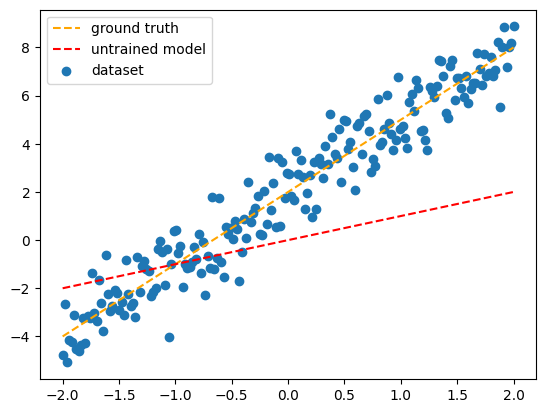

In [7]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

class Modello(tf.Module):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self._w = tf.Variable(1.)
        self._b = tf.Variable(0.)

        self.weights = [self._w]
        self.biases = [self._b]
        self.losses = []

    def __call__(self, x):
        return self._w * x + self._b
    
    def loss(self, y_true, y_pred):
        return tf.reduce_mean(tf.square(y_true - y_pred))
    
    def get_losses(self):
        return self.losses
    

    def train(self, y_true, x, learning_rate = .1):
        with tf.GradientTape() as t:
            current_loss = self.loss(y_true, self.__call__(x))

            dw, db = t.gradient(current_loss, [self._w, self._b])

            self._w.assign_sub(dw * learning_rate)
            self._b.assign_sub(db * learning_rate)

    def training_loop(self, x, y_true, learning_rate = .1, epochs = 10):
        self.losses = []
        for epoch in range(epochs):
            self.train(y_true, x, learning_rate)

            current_loss = self.loss(y_true, self.__call__(x))

            self.weights.append(self._w)
            self.biases.append(self._b)
            self.losses.append(current_loss)

            print(f"\nEpoch {epoch}:\n\t Loss: {current_loss}")



def f(x):
    return 3. * x + 2.

model = Modello()

x = tf.linspace(-2,2, 200)
x = tf.cast(x, tf.float32)

noise = tf.random.normal(shape=x.shape)

y = f(x) + noise


y_untrained = model(x)

plt.plot(x, f(x),'--' ,label="ground truth", color="orange")
plt.plot(x, y_untrained,'--' ,label="untrained model", color="red")
plt.scatter(x, y, label="dataset")
plt.legend()

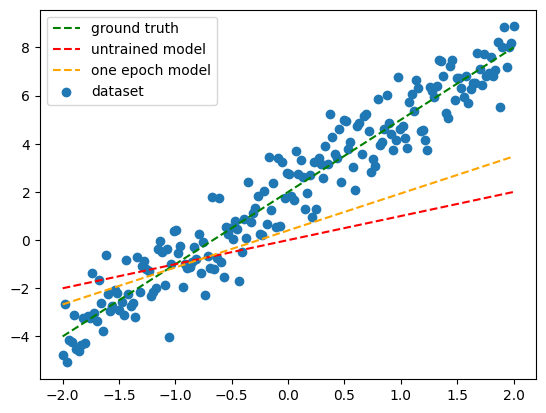

In [8]:
model.train(y,x)
y_first_train = model(x)

plt.plot(x, f(x),'--' ,label="ground truth", color="green")
plt.plot(x, y_untrained,'--' ,label="untrained model", color="red")
plt.plot(x, y_first_train,'--' ,label="one epoch model", color="orange")
plt.scatter(x, y, label="dataset")
plt.legend()


Epoch 0:
	 Loss: 4.06803035736084

Epoch 1:
	 Loss: 2.764249801635742

Epoch 2:
	 Loss: 2.0051774978637695

Epoch 3:
	 Loss: 1.5595959424972534

Epoch 4:
	 Loss: 1.2958968877792358

Epoch 5:
	 Loss: 1.1385937929153442

Epoch 6:
	 Loss: 1.0440397262573242

Epoch 7:
	 Loss: 0.9867923855781555

Epoch 8:
	 Loss: 0.9518983364105225

Epoch 9:
	 Loss: 0.9304972887039185


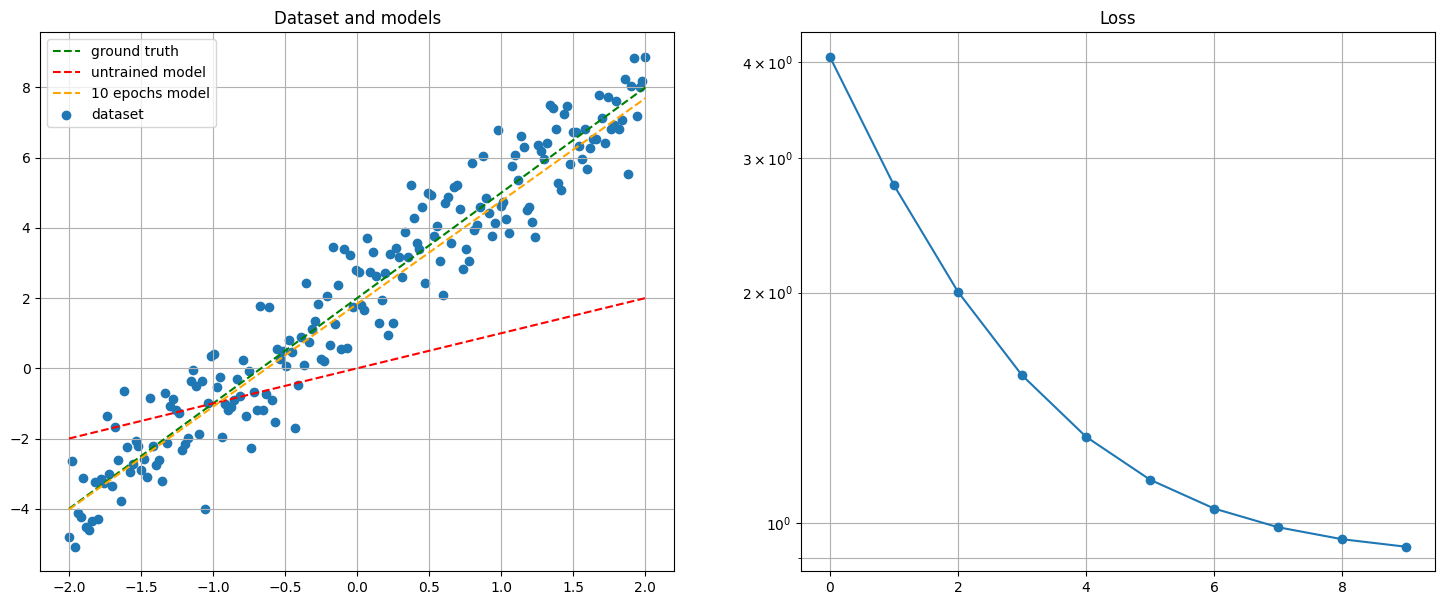

In [9]:
epochs = 10
model.training_loop(x,y, epochs=10)
y_trained = model(x)


fig = plt.figure(figsize=(18,7))
a = plt.subplot(1,2,1)
plt.grid(True, 'both')
plt.title('Dataset and models')
plt.plot(x, f(x),'--' ,label="ground truth", color="green")
plt.plot(x, y_untrained,'--' ,label="untrained model", color="red")
plt.plot(x, y_trained,'--' ,label="10 epochs model", color="orange")
plt.scatter(x, y, label="dataset")
plt.legend()

a = plt.subplot(1,2,2)
plt.semilogy()
plt.title('Loss')
plt.grid(True, 'both', 'both')
plt.plot(range(epochs), model.get_losses(), '-o')
